In [ ]:
from matplotlib import pyplot as plt
from functions import *

# continuous flow with reaction in one 50 ul chip and uv-vis on another 50 ul chip
# mixing due to turbulent flow in the connecting tubing results in EV+. decay, poor coorelation between tR and recorded absorbance  

# V(Ru(bpy)3, 12.5 mM, buffer) = 240 ul
# V(EV, 25 mM, buffer) = 720 ul
# V(EDTA, saturated, buffer) = 540 ul

data = f'./results/260703_Rubpy_EV_EDTA_Flow/'
start = "14-01-00-000" # recorded start time

vrxn = 50 # reaction volume
vfull = 115 # full volume
tbuffer = 30 # time in seconds after the solution fully fills the reaction cell before recording

tRs = [tR*60 for tR in range(1, 8)] # residence times in seconds for 1-7 minutes
flowrates = [flowprop(tR=tR, vol=vrxn) for tR in tRs] # flow rates for each tR
points = [] # times in seconds at which to record absorbance

for i in range(len(tRs)):
    if i == 0:
        prevtime = 0
    else:
        prevtime = points[-1] + tbuffer
    points.append(prevtime + flowprop(flowrate=flowrates[i], vol=vfull) + tRs[i])

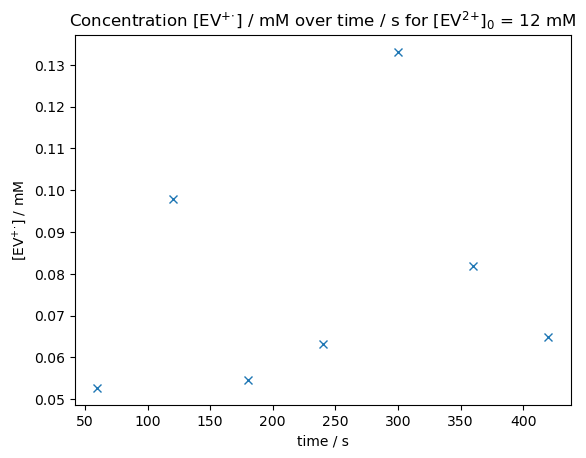

In [ ]:
# concentration vs time plot for each run
c = concvstimepoints(data, 600, 700e-6, 1.22e6, points, start=start)
plt.plot(tRs, [conc*1e3 for conc in c], "x") # plot time in seconds, concentrations in μM
plt.xlabel(r'time / s')
plt.ylabel(r'[EV$^{+\!\cdot\!}$] / mM')
plt.title(r'Concentration [EV$^{+\!\cdot\!}$] / mM over time / s for [EV$^{2\!+\!}$]$_0$ = '
            f'{solprop(cstock=25e-3, valiquot=720e-6, vsol=1.5e-3)*1e3:.0f} mM')
plt.show()

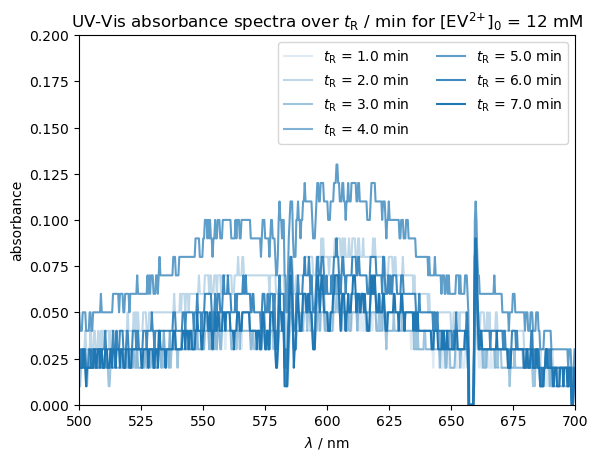

In [ ]:
# absorbance spectra for each tR
l, a = spectrumvstimepoints(data, points,start=start)
for i in range(len(points)):
    plt.plot(l, a[i], color="#1F77B4", alpha=(i+1)/len(points), label=rf'$t_\mathrm{{R}}$ = {tRs[i]/60} min')
plt.title(r"UV-Vis absorbance spectra over $t_\mathrm{R}$ / min for [EV$^{2\!+\!}$]$_0$ = "
            f"{solprop(cstock=25e-3, valiquot=720e-6, vsol=1.5e-3)*1e3:.0f} mM")
plt.xlim(500, 700)
plt.ylim(0, 0.2)
plt.xlabel(r'$\lambda$ / nm')
plt.ylabel(r'absorbance')
plt.legend(ncols=2)
plt.show()